In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


replacing blanks with 0 as a tenure is 0 and no total changes are recorded

In [6]:
df["TotalCharges"] = df["TotalCharges"].replace(" ","0")
df["TotalCharges"] = df["TotalCharges"].astype("float")

In [10]:
df.isnull().sum().sum()

np.int64(0)

In [11]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [15]:
df.duplicated().sum()

np.int64(0)

In [17]:
df["customerID"].duplicated().sum()

np.int64(0)

In [21]:
def conv(value):
  if value == 1:
    return "Yes"
  else:
    return "No"

df['SeniorCitizen'] = df["SeniorCitizen"].apply(conv)

In [23]:
df.head(30)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,No,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes
6,1452-KIOVK,Male,No,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No
7,6713-OKOMC,Female,No,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,No
8,7892-POOKP,Female,No,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,No,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


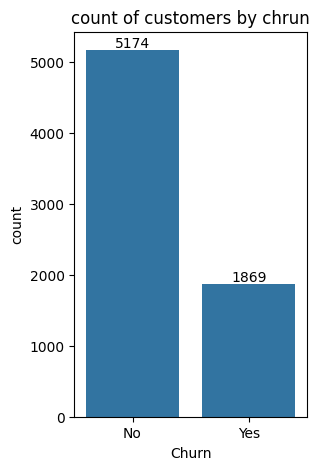

In [58]:
plt.figure(figsize = (3,5))
ax = sns.countplot(x = 'Churn', data = df)

ax.bar_label(ax.containers[0])
plt.title("count of customers by chrun")
plt.show()

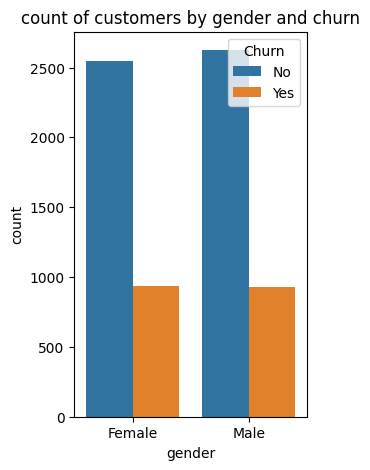

In [57]:
plt.figure(figsize = (3,5))
sns.countplot(x = 'gender', data = df, hue = 'Churn')
plt.title("count of customers by gender and churn")
plt.show()

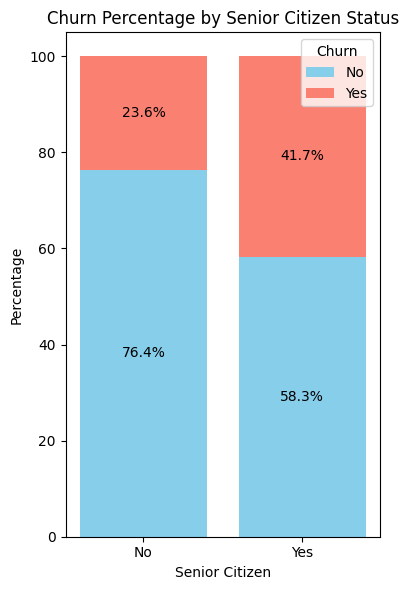

In [60]:
import pandas as pd
import matplotlib.pyplot as plt

# Create a crosstab of counts
ct = pd.crosstab(df['SeniorCitizen'], df['Churn'])

# Convert to percentages (row-wise)
ct_percent = ct.div(ct.sum(axis=1), axis=0) * 100

# Plot
fig, ax = plt.subplots(figsize=(4, 6))

bottom_vals = None
colors = ['skyblue', 'salmon']

# Loop through churn categories to stack bars
for idx, churn_status in enumerate(ct.columns):
    values = ct_percent[churn_status]
    ax.bar(ct_percent.index, values, bottom=bottom_vals, label=churn_status, color=colors[idx])

    # Add text labels
    for i, (val, base) in enumerate(zip(values, bottom_vals if bottom_vals is not None else [0]*len(values))):
        ax.text(i, base + val / 2, f"{val:.1f}%", ha='center', va='center', fontsize=10)

    # Update bottom for stacking
    bottom_vals = values if bottom_vals is None else bottom_vals + values

# Customize plot
ax.set_title("Churn Percentage by Senior Citizen Status")
ax.set_xlabel("Senior Citizen")
ax.set_ylabel("Percentage")
ax.legend(title="Churn")
ax.set_xticks([0, 1])
ax.set_xticklabels(['No', 'Yes'])

plt.tight_layout()
plt.show()


comparative a greater percentage of people in seniorcitizen category have churned

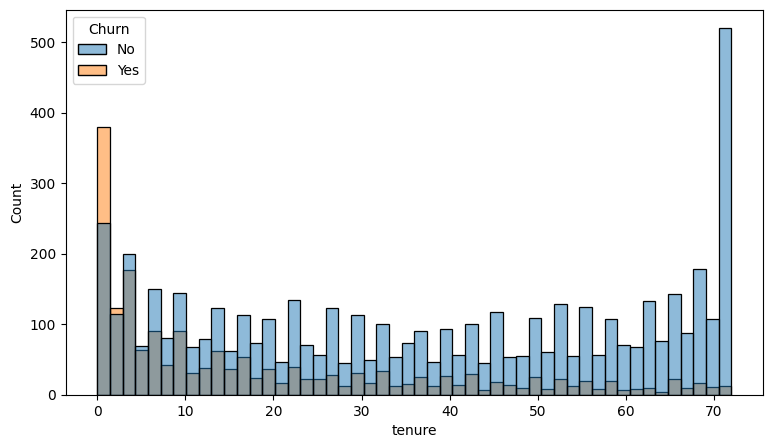

In [65]:
plt.figure(figsize = (9,5))
sns.histplot(x = 'tenure', data = df, hue = 'Churn', bins=50)
plt.show()

people  who have used our serices for a long time have stayed and people  who have used our sevices #1 or 2  months have churned

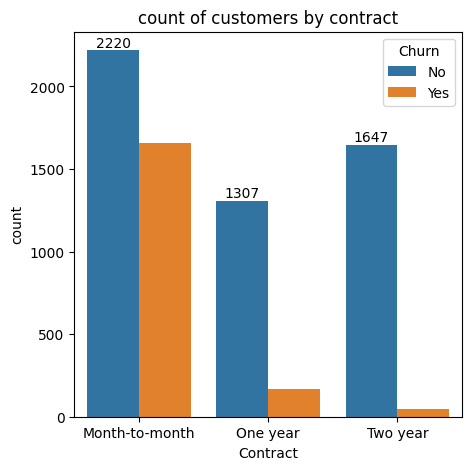

In [72]:
plt.figure(figsize = (5,5))
ax = sns.countplot(x = 'Contract', data = df, hue = "Churn")
ax.bar_label(ax.containers[0])
plt.title("count of customers by contract")
plt.show()

people who have months to month contract are likely to churn then from those who have 1or 2 year or contract

In [74]:
df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

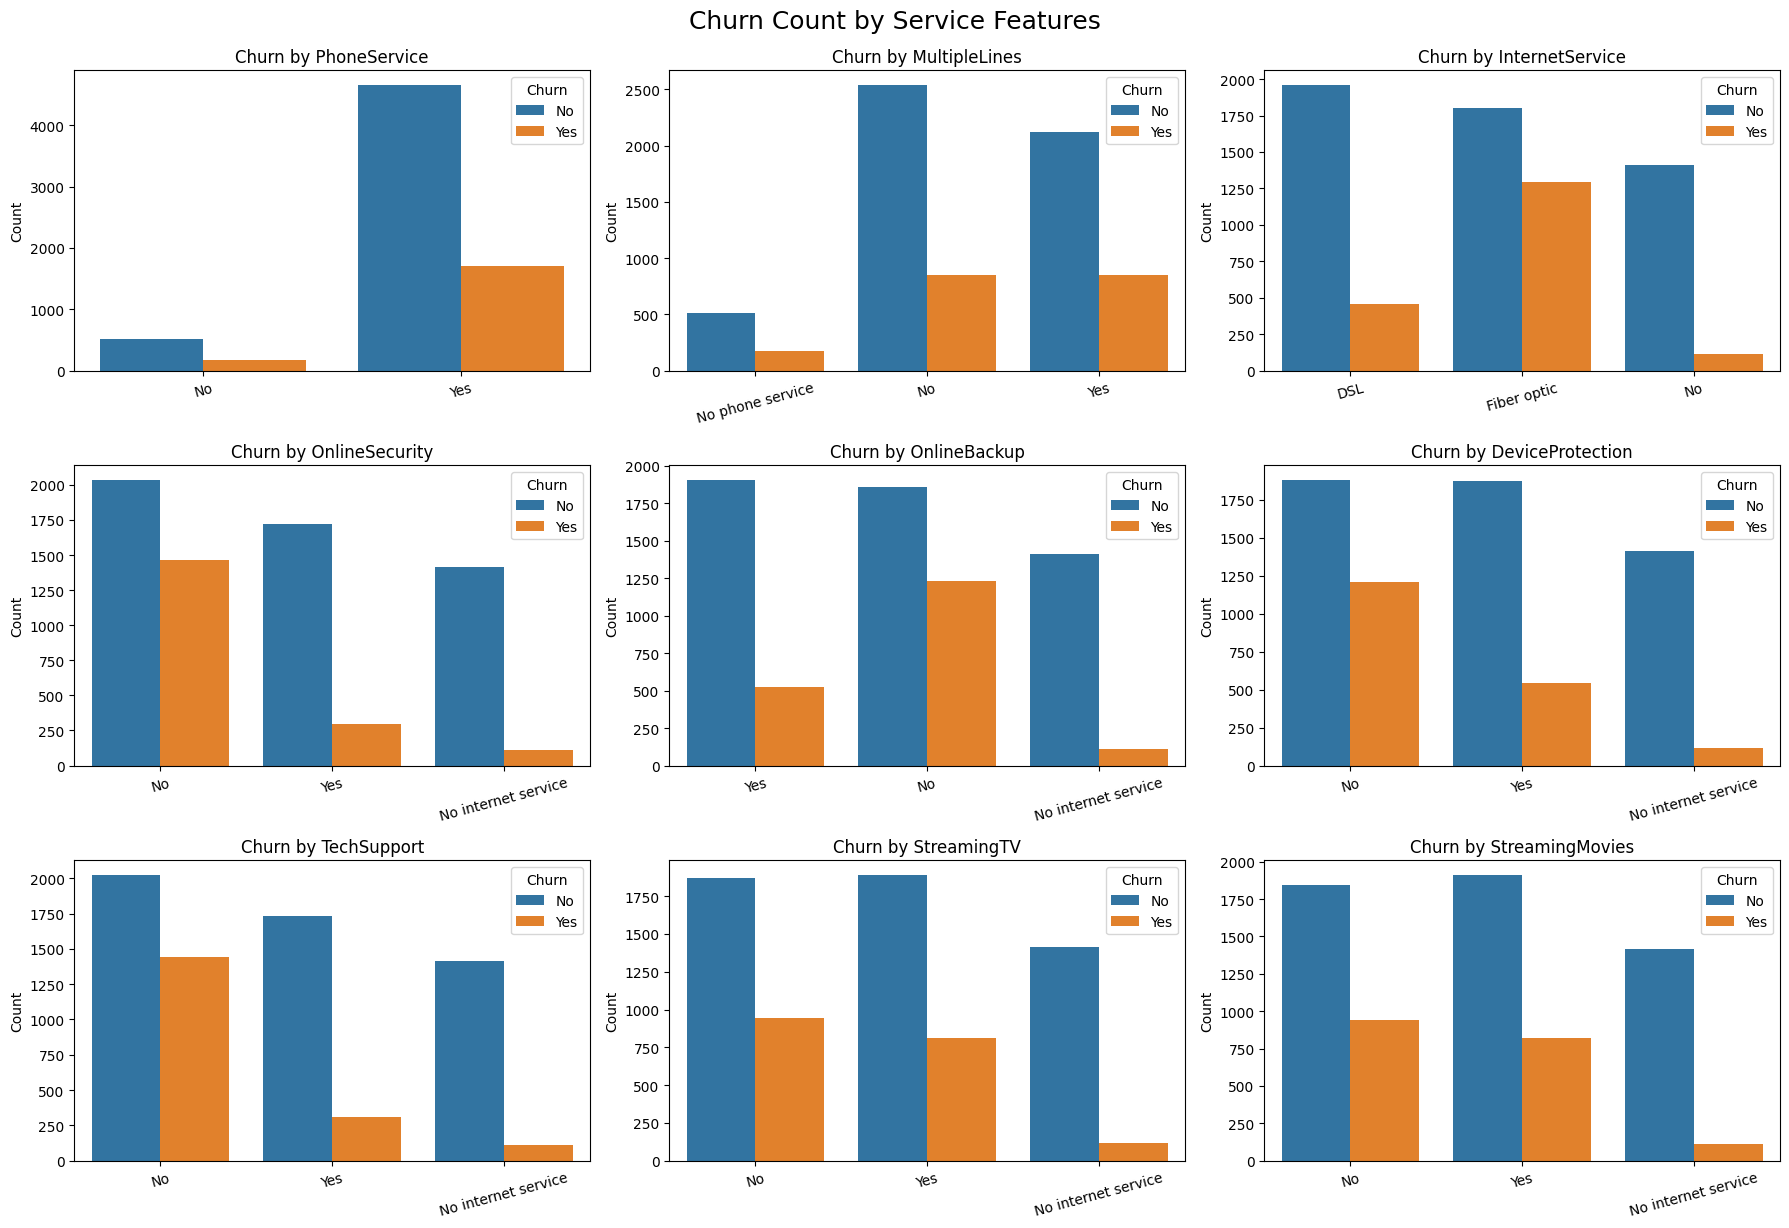

In [80]:
# List of features to plot
features = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# Set up the figure and axes (3x3 grid)
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

# Plot each feature
for i, feature in enumerate(features):
    ax = axes[i]
    sns.countplot(data=df, x=feature, hue='Churn', ax=ax)
    ax.set_title(f'Churn by {feature}')
    ax.set_xlabel('')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=15)

# Adjust layout and add a title
plt.tight_layout()
plt.suptitle('Churn Count by Service Features', fontsize=18, y=1.02)
plt.show()


Customers with no internet service tend to have very low churn, as seen across features like OnlineSecurity, TechSupport, StreamingTV, etc.

Fiber optic internet users show higher churn rates compared to DSL and no internet.

Features like OnlineSecurity, TechSupport, and DeviceProtection show a clear pattern: those not using the service churn more.

Phone service and multiple lines have relatively lower impact on churn compared to internet-related services.

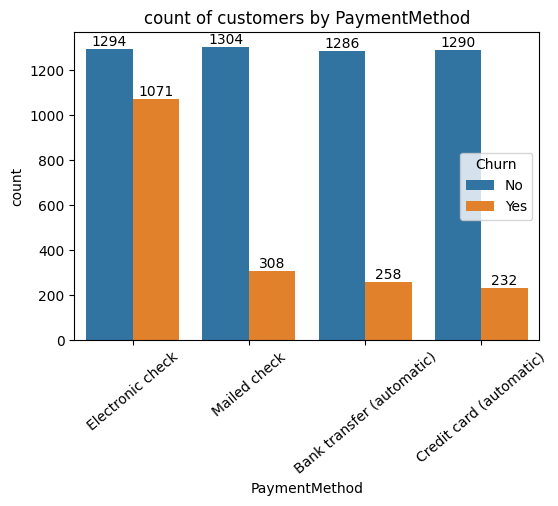

In [85]:
plt.figure(figsize = (6,4))
ax = sns.countplot(x = 'PaymentMethod', data = df, hue = "Churn")
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("count of customers by PaymentMethod")
plt.xticks (rotation =40)
plt.show()

custumer is likely  to churn when he is using electronic check as a payment method